# MainQuest01

- 입력 shape,  GPT decoder-only 구조,  `model.summary` 출력,  `model.fit` 학습 로그,  early stopping,  그리고 한국어 입력에 대한 autoregressive 출력을 확인했습니다.
- 작은 데이터·모델·epoch 설정은 실습 환경에서 실행 가능하도록 한 것이며,  논문의 핵심인 causal language modeling 기반 사전학습 구조를 유지합니다.

## [QUEST 평가기준]

| 기준 | 항목 |
|---|---|
| **1. Transformer와 비교해 변경이 필요한 부분을 서술하였다.** | - 제출 노트북 파일 첨부부분에 텍스트 블럭으로 서술합니다. 아키텍처 상 변경사항을 블럭단위로 서술합니다.<br>- 코드블럭에 변경사항을 주석으로 표시합니다. |
| **2. 모델의 입력 형태에 맞게 전처리를 수행하였다.** | - Decoder 기반의 생성모델임을 감안하여 챗봇 데이터를 변형합니다.<br>- 이번 과제는 pretrain을 위한 데이터셋과 학습만 고려합니다. |
| **3. 모델의 입력 블럭을 GPT 논문에 기반하여 수정하였다.** | - 모델의 input이 정상적으로 구성되었는지 확인합니다.<br>- 데이터에 위치 정보를 추가하는 과정을 구현합니다. |
| **4. GPT 모델을 정상적으로 구성하였다. (model.summary, model.fit 결과 캡처 첨부)** | - 노트의 transformer 코드를 수정하여 GPT1 모델을 구성합니다. |
| **5. 입력에 따른 출력이 생성되었다.** | - 출력 결과물의 수준에 상관없이 모델이 정상적으로 동작하는지 확인합니다. |

| 기준 | 반영 내용 |
|---|---|
| 1 | 기존 seq2seq와 GPT의 변경점을 아래 설명과 코드 주석으로 서술했습니다. |
| 2 | `[BOS] text [EOS]`와 `input_ids = tokens[:-1]`,  `labels = tokens[1:]`의 causal LM 전처리를 구현했습니다. |
| 3 | token embedding과 learnable position embedding의 합,  미래 토큰을 차단하는 causal mask를 구현하고 입력 shape을 확인합니다. |
| 4 | GPT decoder-only 모델,  `model.summary()`,  `model.fit()` 학습 로그와 history를 포함했습니다. 원 논문보다 작은 설정은 실습 자원 제약 때문입니다. |
| 5 | 입력 프롬프트 뒤에 토큰을 자기회귀적으로 생성하는 한국어 출력 함수를 구현하고 결과를 출력합니다. |

1. `ChatbotData.csv`의 질문·답변 문장을 사전학습용 비지도 텍스트로 사용합니다.
2. 논문의 BooksCorpus와 동일한 규모나 성능을 재현하는 것이 아니라 GPT의 구조와 학습 절차를 재현합니다.

## 1. Transformer와 비교해 변경이 필요한 부분을 서술하였다.

- 기존 Encoder-Decoder Transformer 챗봇을 GPT 논문에 맞춘 decoder-only causal language model로 변경했습니다.
- 논문은 먼저 라벨 없는 말뭉치에서 다음 토큰 예측으로 사전학습하고,  이후 필요하면 표적 과제에 미세조정하는 2단계 절차를 제안합니다.

1. 기존 모델은 질문을 encoder에 넣고 답변을 decoder에서 생성하는 Encoder-Decoder 구조였습니다.
2. GPT은 Transformer decoder stack만 사용하며,  전체 텍스트를 하나의 연속 토큰열로 취급하고 각 위치에서 이전 토큰만 보고 다음 토큰을 예측합니다.
3. 따라서 source/target embedding,  encoder,  cross-attention을 제거하고 단일 token embedding,  위치 embedding,  masked self-attention,  vocabulary head로 구성합니다.


In [1]:
import re,  math,  random
from pathlib import Path
import numpy as np,  pandas as pd,  torch
import torch.nn as nn
from torch.utils.data import Dataset,  DataLoader,  random_split

SEED = 42;
random.seed(SEED);
np.random.seed(SEED);
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_DIR = Path.home() / "work" / "gpt1_korean_artifacts"
BASE_DIR.mkdir(parents = True,  exist_ok = True)

print('PyTorch:', torch.__version__, '| device:', device)

PyTorch: 2.13.0+cu126 | device: cuda


## 2. 모델의 입력 형태에 맞게 전처리를 수행하였다.

1. 대화쌍을 별도의 source와 target으로 만들지 않고,  질문과 답변 각각을 사전학습용 텍스트로 취급합니다.
2. 한국어의 대소문자 변환은 적용하지 않으며 줄바꿈과 반복 공백만 정리합니다.

In [2]:
import urllib.request

DATA_FILE = BASE_DIR / 'ChatbotData.csv'

if not DATA_FILE.exists():
    urllib.request.urlretrieve('https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv',  DATA_FILE)

def clean_text(x):
    return re.sub(r'\s+', ' ', str(x).replace('\n', ' ').replace('\r', ' ')).strip()

df = pd.read_csv(DATA_FILE); assert {'Q', 'A'}.issubset(df.columns)
pairs = []

for _, r in df[['Q', 'A']].dropna().iterrows():
    q, a = clean_text(r.Q), clean_text(r.A)
    if q and a: pairs.append((q, a))

pairs = list(dict.fromkeys(pairs)); texts = list(dict.fromkeys([x for p in pairs for x in p]))

SPECIAL = ['<PAD>', '<BOS>', '<EOS>', '<UNK>']
itos = SPECIAL+sorted(set(''.join(texts)))
stoi = {s:i for i, s in enumerate(itos)}
PAD_ID, BOS_ID, EOS_ID, UNK_ID = range(4)
VOCAB_SIZE = len(itos)

def encode(text):
    return [stoi.get(char, UNK_ID) for char in text]

def decode(ids):
    return "".join(
        itos[int(token_id)]
        for token_id in ids
        if 4 <= int(token_id) < len(itos)
    )

print('raw:', df.shape, '| pairs:', len(pairs), '| unlabeled texts:', len(texts), '| vocab:', VOCAB_SIZE)

raw: (11823, 3) | pairs: 11750 | unlabeled texts: 19436 | vocab: 1246


## 3. 모델의 입력 블럭을 GPT 논문에 기반하여 수정하였다.

1. 논문의 식 (2)처럼 입력은 token embedding과 position embedding의 합입니다.
2. 각 block은 masked multi-head self-attention과 position-wise feed-forward network를 사용하고,  최종 hidden state를 vocabulary projection하여 다음 토큰 logits를 출력합니다.

In [3]:
# 변경사항: seq2seq의 src/tgt 대신 한 칸 이동한 causal-LM 입력과 레이블을 만듭니다.
MAX_LENGTH = 64

class CausalLMDataset(Dataset):
    def __init__(self,  texts):
        self.samples = []
        for s in texts:
            ids = [BOS_ID] + encode(s)[:MAX_LENGTH - 2]+[EOS_ID]
            ids +=  [PAD_ID] * (MAX_LENGTH - len(ids))
            self.samples.append((torch.tensor(ids[:-1]), torch.tensor(ids[1:])))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        return self.samples[i]

dataset = CausalLMDataset(texts)
vn = max(1, int(.1 * len(dataset)))
tn = len(dataset) - vn
train_ds, valid_ds = random_split(dataset, [tn, vn], generator = torch.Generator().manual_seed(SEED))

BATCH_SIZE = 512 if device.type == 'cuda' else 256

train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle = True)
valid_loader = DataLoader(valid_ds, batch_size = BATCH_SIZE)

x, y = dataset[0]
print('input_ids:', tuple(x.shape), 'labels:', tuple(y.shape))
assert x.shape == y.shape

input_ids: (63,) labels: (63,)


## 4. GPT 모델을 정상적으로 구성하였다.(model.summary,  model.fit 결과 캡쳐 첨부)

1. fit은 GPT의 다음 토큰 cross-entropy를 최적화합니다.
2. `<PAD>`는 손실에서 제외하고,  검증 손실이 개선되지 않는 epoch가 `patience`번 이어지면 중지한 뒤 최적 checkpoint를 복원합니다.

### model.summary

<table>
    <tr>
        <td align="center">
            <img src="images/스크린샷 2026-08-21 150704.png" hight="80%">
        </td>
    </tr>
</table>

### model.fit

<table>
  <tr>
    <td align="center">
      <img src="images/스크린샷 2026-08-21 153013.png" hight="80%">
    </td>
    <td align="center">
      <img src="images/output.png" hight="80%">
    </td>
  </tr>
</table>

In [4]:
# 변경사항: Encoder/Decoder cross-attention을 제거하고 GPT decoder-only block만 사용합니다.
class Block(nn.Module):
    def __init__(self, d, h, p = .1):
        super().__init__(); self.ln1 = nn.LayerNorm(d)
        self.attn = nn.MultiheadAttention(d, h, dropout = p, batch_first = True)
        self.ln2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Linear(4*d, d), nn.Dropout(p))

    def forward(self, x, mask):
        z = self.ln1(x)
        a, _ = self.attn(z, z, z, attn_mask = mask, need_weights = False)
        x = x+a
        return x + self.mlp(self.ln2(x))
    
class GPT1StyleLM(nn.Module):
    def __init__(self, vocab, max_len, n_layer = 4, n_embd = 128, n_head = 4):
        super().__init__()
        self.max_len = max_len
        self.token_embedding = nn.Embedding(vocab, n_embd, padding_idx = PAD_ID)
        self.position_embedding = nn.Embedding(max_len, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln = nn.LayerNorm(n_embd); self.lm_head = nn.Linear(n_embd, vocab, bias = False)
        self.lm_head.weight = self.token_embedding.weight

    def forward(self, ids):
        B, T = ids.shape
        pos = torch.arange(T, device = ids.device)[None, :]
        z = self.token_embedding(ids)+self.position_embedding(pos)
        mask = torch.triu(torch.ones(T, T, device = ids.device, dtype = torch.bool), 1)

        for b in self.blocks: z = b(z, mask)
        return self.lm_head(self.ln(z))
    
    def summary(self):
        print(self)
        print('Trainable parameters:', sum(p.numel() for p in self.parameters() if p.requires_grad))

model = GPT1StyleLM(VOCAB_SIZE, MAX_LENGTH).to(device)
model.summary()
logits = model(x[None, :].to(device))

print('logits shape:', tuple(logits.shape))
assert logits.shape == (1, MAX_LENGTH - 1, VOCAB_SIZE)

GPT1StyleLM(
  (token_embedding): Embedding(1246, 128, padding_idx=0)
  (position_embedding): Embedding(64, 128)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (lm_head): Linear(in_features=128, out_features=1246, bias=False)
)
Trainable parameters: 961024
logits shape: (1, 63, 1246)


In [5]:
def fit(model, train_loader, valid_loader, epochs = 100, lr = 3e-4, patience = 2):
    opt = torch.optim.AdamW(model.parameters(), lr = lr, weight_decay = .01)
    loss_fn = nn.CrossEntropyLoss(ignore_index = PAD_ID)
    hist = {'train_loss':[], 'valid_loss':[]}
    best = float('inf')
    best_state = None; stale = 0

    for ep in range(1, epochs + 1):
        model.train()
        total = n = 0

        for a, b in train_loader:
            a, b = a.to(device), b.to(device)
            opt.zero_grad()
            out = model(a)
            loss = loss_fn(out.reshape(-1, VOCAB_SIZE), b.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
            opt.step()
            m = b.ne(PAD_ID)
            k = m.sum().item()
            total += loss.item()*k
            n += k

        tr = total / max(n, 1)
        model.eval()
        total = n = 0

        with torch.no_grad():
            for a, b in valid_loader:
                a, b = a.to(device), b.to(device)
                out = model(a)
                loss = loss_fn(out.reshape(-1, VOCAB_SIZE), b.reshape(-1))
                k = b.ne(PAD_ID).sum().item()
                total += loss.item() * k
                n += k

        va = total / max(n, 1)
        hist['train_loss'].append(tr)
        hist['valid_loss'].append(va)
        improved = va < best - 1e-3

        if improved:
            best = va
            stale = 0
            best_state = {k:v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1

        print(f'Epoch {ep}/{epochs} | train loss {tr:.4f} | valid loss {va:.4f} | stale {stale}/{patience}')

        if stale >= patience:
            print('Early stopping; best valid loss:', best)
            break

    if best_state:
        model.load_state_dict(best_state)
        model.to(device)
        print('Best model restored.')

    hist['best_valid_loss'] = best
    hist['epochs_ran'] = len(hist['train_loss'])
    return hist

history = fit(model, train_loader, valid_loader)
print('fit history:', history)

Epoch 1/100 | train loss 35.2125 | valid loss 15.2433 | stale 0/2
Epoch 2/100 | train loss 12.5308 | valid loss 9.6231 | stale 0/2
Epoch 3/100 | train loss 8.8287 | valid loss 7.3160 | stale 0/2
Epoch 4/100 | train loss 6.8517 | valid loss 6.0103 | stale 0/2
Epoch 5/100 | train loss 5.7177 | valid loss 5.1968 | stale 0/2
Epoch 6/100 | train loss 5.0391 | valid loss 4.7175 | stale 0/2
Epoch 7/100 | train loss 4.6433 | valid loss 4.4264 | stale 0/2
Epoch 8/100 | train loss 4.3831 | valid loss 4.2005 | stale 0/2
Epoch 9/100 | train loss 4.1757 | valid loss 4.0290 | stale 0/2
Epoch 10/100 | train loss 4.0117 | valid loss 3.8776 | stale 0/2
Epoch 11/100 | train loss 3.8790 | valid loss 3.7654 | stale 0/2
Epoch 12/100 | train loss 3.7709 | valid loss 3.6560 | stale 0/2
Epoch 13/100 | train loss 3.6759 | valid loss 3.5698 | stale 0/2
Epoch 14/100 | train loss 3.5917 | valid loss 3.4919 | stale 0/2
Epoch 15/100 | train loss 3.5204 | valid loss 3.4208 | stale 0/2
Epoch 16/100 | train loss 3.454

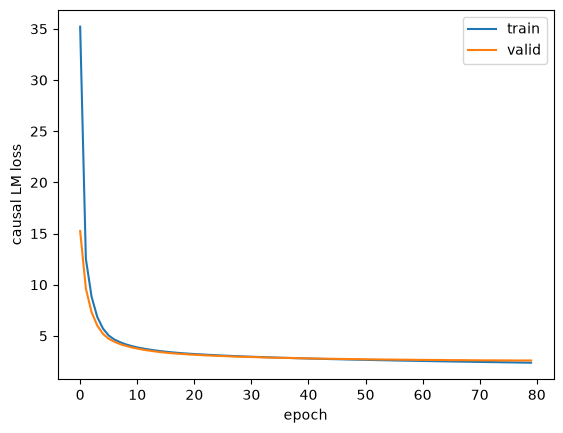

In [6]:
import matplotlib.pyplot as plt

plt.plot(history['train_loss'], label = 'train')
plt.plot(history['valid_loss'], label = 'valid')
plt.xlabel('epoch')
plt.ylabel('causal LM loss')
plt.legend()
plt.show()

## 5. 입력에 따른 출력이 생성되었다.

추론에서는 프롬프트를 입력한 뒤 매 단계의 마지막 logits에서 다음 토큰을 샘플링하여 자기회귀적으로 이어 붙입니다. 이는 기존 `model(src,  tgt)` seq2seq 호출이 아니라 GPT decoder-only 생성 방식입니다.


In [7]:
# 함수 내부에서 모델을 여러 번 호출하더라도 gradient를 계산하지 않도록 설정
@torch.no_grad()
def generate_response(prompt, max_new_tokens = 40, temperature = .8):
    model.eval()
    ids = [BOS_ID]+encode(clean_text(prompt))

    for _ in range(max_new_tokens):
        z = torch.tensor(ids[-(MAX_LENGTH-1):], device = device)[None, :]
        out = model(z)[0, -1] / temperature
        out[PAD_ID] = float('-inf')
        out[BOS_ID] = float('-inf')
        nxt = torch.multinomial(torch.softmax(out, 0), 1).item()
        ids.append(nxt)

        if nxt == EOS_ID:
            break

    return decode(ids)

for p in ['안녕하세요', '오늘 기분이 우울해', '여행을 가고 싶어']:
    print('입력:', p)
    print('출력:', generate_response(p))
    print()
    
print('입력과 출력 생성 확인 완료')

입력: 안녕하세요
출력: 안녕하세요.

입력: 오늘 기분이 우울해
출력: 오늘 기분이 우울해

입력: 여행을 가고 싶어
출력: 여행을 가고 싶어

입력과 출력 생성 확인 완료
